# Veriye İlk Bakış

In [2]:
import seaborn as sns

planets = sns.load_dataset("planets")

planets.head(6)

,method,number,orbital_period,mass,distance,year
0,Radial Velocity,1,269.300,7.10,77.40,2006
1,Radial Velocity,1,874.774,2.21,56.95,2008
2,Radial Velocity,1,763.000,2.60,19.84,2011
3,Radial Velocity,1,326.030,19.40,110.62,2007
4,Radial Velocity,1,516.220,10.50,119.47,2009
5,Radial Velocity,1,185.840,4.80,76.39,2008


## Veriseti elimize geçtikten sonra yapılacaklar
**1)** Verisetinin hikayesi nedir: veriseti içerisindeki değerlerin nasıl oluştuğunu sorgulamak gerekir. Yani verisetinin sorgulanması gerekir. Değişkenlerin nasıl oluştuğunu bilmemiz gerekiyor. 

**2)** Verisetini kopyala:

In [5]:
df = planets.copy() # veri elimize geçtikten sonra ilk yapılması önerilen şey, verinin kopyalanmasıdır

In [6]:
df.head(5)

,method,number,orbital_period,mass,distance,year
0,Radial Velocity,1,269.300,7.10,77.40,2006
1,Radial Velocity,1,874.774,2.21,56.95,2008
2,Radial Velocity,1,763.000,2.60,19.84,2011
3,Radial Velocity,1,326.030,19.40,110.62,2007
4,Radial Velocity,1,516.220,10.50,119.47,2009


In [7]:
df.tail(5)

,method,number,orbital_period,mass,distance,year
1030,Transit,1,3.941507,NaN,172.0,2006
1031,Transit,1,2.615864,NaN,148.0,2007
1032,Transit,1,3.191524,NaN,174.0,2007
1033,Transit,1,4.125083,NaN,293.0,2008
1034,Transit,1,4.187757,NaN,260.0,2008


**3)** Verisetinin yapısal bilgilerine ulaşılması gerek

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1035 entries, 0 to 1034
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   method          1035 non-null   object 
 1   number          1035 non-null   int64  
 2   orbital_period  992 non-null    float64
 3   mass            513 non-null    float64
 4   distance        808 non-null    float64
 5   year            1035 non-null   int64  
dtypes: float64(3), int64(2), object(1)
memory usage: 48.6+ KB


Hemen bir önceki satırda olan veriseti hakkındaki yapısal bilgiler:
1) RangeIndex: Gözlem sayısı(Satırlar) = 1035 adet
2) Değişkenler(Sütunlar) = 6 adet
3) Her değişkenin veritipi(object, int64, float64......)(object kategorik değişken demektir)
4) Ram'de kapladığı alan = 48.6 KB

In [11]:
df.dtypes # dataset içerisindeki değişkenlerin veritipleri

method             object
number              int64
orbital_period    float64
mass              float64
distance          float64
year                int64
dtype: object

In [12]:
# Daha sonra kullanacağımız fonksiyonlar, kütüphaneler gibi araçlarda object türü sıkıntı çıkartabilir
# Bu object türlerini Category isimli başka bir veritipine çevirmek, ilerde yaşayacağımız problemleri azaltacaktr

import pandas as pd

df.method = pd.Categorical(df.method) # df içerisindeki object türünde olan method sütununu categorical tipine çevirdik

df.dtypes # görüldüğü üzere datatype'ı category oldu

method            category
number               int64
orbital_period     float64
mass               float64
distance           float64
year                 int64
dtype: object

## Verisetinin Betimlenmesi

In [14]:
import seaborn as sns

planets = sns.load_dataset("planets")

df=planets.copy()

df.head(6)

,method,number,orbital_period,mass,distance,year
0,Radial Velocity,1,269.300,7.10,77.40,2006
1,Radial Velocity,1,874.774,2.21,56.95,2008
2,Radial Velocity,1,763.000,2.60,19.84,2011
3,Radial Velocity,1,326.030,19.40,110.62,2007
4,Radial Velocity,1,516.220,10.50,119.47,2009
5,Radial Velocity,1,185.840,4.80,76.39,2008


In [15]:
df.shape # satır(1035) ve sütun(6) sayıları

(1035, 6)

In [16]:
df.columns # sütunların adları

Index(['method', 'number', 'orbital_period', 'mass', 'distance', 'year'], dtype='object')

In [17]:
df.describe().T 

# betimsel istatistikleri bir arada verir. T ile transpose, yani farklı halini aldık
# bu fonksiyon eksik gözlemleri göz ardı eder ve kategorik değişkeleri dışarıda bırakır. Bu bilginin göz ardı edilmemesi gerekir.

,count,mean,std,min,25%,50%,75%,max
number,1035.0,1.785507,1.240976,1.000000,1.00000,1.0000,2.000,7.0
orbital_period,992.0,2002.917596,26014.728304,0.090706,5.44254,39.9795,526.005,730000.0
mass,513.0,2.638161,3.818617,0.003600,0.22900,1.2600,3.040,25.0
distance,808.0,264.069282,733.116493,1.350000,32.56000,55.2500,178.500,8500.0
year,1035.0,2009.070531,3.972567,1989.000000,2007.00000,2010.0000,2012.000,2014.0


In [18]:
df.describe(include="all").T # yaparak tüm değerleri bu tabloda görebiliriz ancak hiç anlamlı bir şey elde etmiş olmayacağız 

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
method,1035,10,Radial Velocity,553,NaN,NaN,NaN,NaN,NaN,NaN,NaN
number,1035.0,NaN,NaN,NaN,1.785507,1.240976,1.0,1.0,1.0,2.0,7.0
orbital_period,992.0,NaN,NaN,NaN,2002.917596,26014.728304,0.090706,5.44254,39.9795,526.005,730000.0
mass,513.0,NaN,NaN,NaN,2.638161,3.818617,0.0036,0.229,1.26,3.04,25.0
distance,808.0,NaN,NaN,NaN,264.069282,733.116493,1.35,32.56,55.25,178.5,8500.0
year,1035.0,NaN,NaN,NaN,2009.070531,3.972567,1989.0,2007.0,2010.0,2012.0,2014.0


## Eksik Değerlerin İncelenmesi

Bu konu komple bir bölüm ayrılacak kadar büyük. Şimdi, burada sadece basit birkaç çözümden bahsedip konuyu üstünkörü geçeceğiz, sonradan çok derinlemesine inceleyeceğiz.

In [21]:
import seaborn as sns

planets = sns.load_dataset("planets")

df=planets.copy()

df.head(6)

,method,number,orbital_period,mass,distance,year
0,Radial Velocity,1,269.300,7.10,77.40,2006
1,Radial Velocity,1,874.774,2.21,56.95,2008
2,Radial Velocity,1,763.000,2.60,19.84,2011
3,Radial Velocity,1,326.030,19.40,110.62,2007
4,Radial Velocity,1,516.220,10.50,119.47,2009
5,Radial Velocity,1,185.840,4.80,76.39,2008


In [22]:
# Dataset'de hiç eksik gözlem(değer) var mı sorgulaması:

df.isnull().values.any() 

True

In [23]:
# Hangi sütunlarda var?

df.isnull().any()

method            False
number            False
orbital_period     True
mass               True
distance           True
year              False
dtype: bool

In [24]:
# Hangi sütınlarda kaç adet var?

df.isnull().sum()

method              0
number              0
orbital_period     43
mass              522
distance          227
year                0
dtype: int64

In [25]:
# Dataset içerisindeki eksik, yani NaN olan değerlerin yerine 0 verebiliriz. Bu da hesaplamalarda daha az sorun çıkmasına sebep olur
# ancak eksik değerin neden olduğu, bu değerleri başka bir şey ile doldurmadan önce sorgulanmalıdır çünkü mantıklı sebeplerden de eksik olabilir

df["mass"].fillna(0) 

# Eğer kalıcı olmasını istersek fillna(0, inplae=True) diyebiliriz
# sıfır yerine df.mass.mean() gibi değerler de verebiliriz.

0        7.10
1        2.21
2        2.60
3       19.40
4       10.50
        ...  
1030     0.00
1031     0.00
1032     0.00
1033     0.00
1034     0.00
Name: mass, Length: 1035, dtype: float64

In [26]:
df.fillna(df.mass.mean()) # datasetteki tüm eksik değerler yerine, mass verisinin ortalaması atandı. inplace=True yaparsak kalıcı olur

,method,number,orbital_period,mass,distance,year
0,Radial Velocity,1,269.300000,7.100000,77.40,2006
1,Radial Velocity,1,874.774000,2.210000,56.95,2008
2,Radial Velocity,1,763.000000,2.600000,19.84,2011
3,Radial Velocity,1,326.030000,19.400000,110.62,2007
4,Radial Velocity,1,516.220000,10.500000,119.47,2009
...,...,...,...,...,...,...
1030,Transit,1,3.941507,2.638161,172.00,2006
1031,Transit,1,2.615864,2.638161,148.00,2007
1032,Transit,1,3.191524,2.638161,174.00,2007
1033,Transit,1,4.125083,2.638161,293.00,2008


## Kategorik Değişken Özetleri

Kategorik değişkenler, bir veribilimcisinin günlük iş hayatında anlamak için en çok zaman harcadığı, en çok zaman kaybedilen kısımdır.

In [29]:
import seaborn as sns

planets = sns.load_dataset("planets")

df=planets.copy()

df.head(6)

,method,number,orbital_period,mass,distance,year
0,Radial Velocity,1,269.300,7.10,77.40,2006
1,Radial Velocity,1,874.774,2.21,56.95,2008
2,Radial Velocity,1,763.000,2.60,19.84,2011
3,Radial Velocity,1,326.030,19.40,110.62,2007
4,Radial Velocity,1,516.220,10.50,119.47,2009
5,Radial Velocity,1,185.840,4.80,76.39,2008


**Sadece Kategorik Değişkenler Çekmek ve Bunları Özetlemek:**

In [31]:
cat_df = df.select_dtypes(include=["object"])

cat_df.head() # categoric değişkenler sadece method sütununda olduğundan onu getirdi

,method
0,Radial Velocity
1,Radial Velocity
2,Radial Velocity
3,Radial Velocity
4,Radial Velocity


**Kategorik Değişkenin Sınıflarına(Değerlerine) ve Sınıf(Değer) Sayısına Erişmek**

In [33]:
cat_df.method.unique() # method sütunundakş birbirinden farklı değerlerin neler olduklarını getirdi. kategori türlerini yani

array(['Radial Velocity', 'Imaging', 'Eclipse Timing Variations',
       'Transit', 'Astrometry', 'Transit Timing Variations',
       'Orbital Brightness Modulation', 'Microlensing', 'Pulsar Timing',
       'Pulsation Timing Variations'], dtype=object)

In [34]:
cat_df["method"].value_counts().count() 

# hemen bir önceki satırda yaptığımız şeyi sayısal olarak aldık. Yani birbirinden farklı 10 adet değer var method sütununda

10

**Kategorik Değişkenin Sınıflarının(Değerlerinin) Frekanslarına Erişmek**

Yani hangi benzersiz değerden kaç adet var

In [36]:
cat_df["method"].value_counts()

method
Radial Velocity                  553
Transit                          397
Imaging                           38
Microlensing                      23
Eclipse Timing Variations          9
Pulsar Timing                      5
Transit Timing Variations          4
Orbital Brightness Modulation      3
Astrometry                         2
Pulsation Timing Variations        1
Name: count, dtype: int64

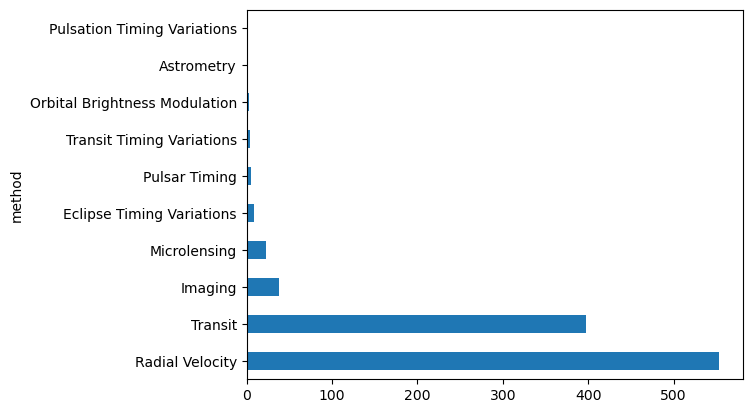

In [37]:
df["method"].value_counts().plot.barh(); 

# bir önceki hücrede yapılan işlemi veriyi görselleştirdik/grafikleştirdik!
# barh eklemek, sütun grafiği ver demektir

## Sürekli Değişken(Kategorik Olmayan) Özetleri

In [39]:
import pandas as pd
import seaborn as sns

planets = sns.load_dataset("planets")

df = planets.copy()

df.head(4)

,method,number,orbital_period,mass,distance,year
0,Radial Velocity,1,269.300,7.10,77.40,2006
1,Radial Velocity,1,874.774,2.21,56.95,2008
2,Radial Velocity,1,763.000,2.60,19.84,2011
3,Radial Velocity,1,326.030,19.40,110.62,2007


In [40]:
df_num = df.select_dtypes(include=["float","int"]) # DataFrame'imizden, datasetimizin sadece sayısal verilerine sahip bir dataframe daha oluşturduk

df_num.head(4)

,number,orbital_period,mass,distance,year
0,1,269.300,7.10,77.40,2006
1,1,874.774,2.21,56.95,2008
2,1,763.000,2.60,19.84,2011
3,1,326.030,19.40,110.62,2007


In [41]:
df_num.describe().T

,count,mean,std,min,25%,50%,75%,max
number,1035.0,1.785507,1.240976,1.000000,1.00000,1.0000,2.000,7.0
orbital_period,992.0,2002.917596,26014.728304,0.090706,5.44254,39.9795,526.005,730000.0
mass,513.0,2.638161,3.818617,0.003600,0.22900,1.2600,3.040,25.0
distance,808.0,264.069282,733.116493,1.350000,32.56000,55.2500,178.500,8500.0
year,1035.0,2009.070531,3.972567,1989.000000,2007.00000,2010.0000,2012.000,2014.0


In [42]:
df_num["mass"].describe().T # şeklinde sadece istediğimiz değer için de yapabiliriz

count    513.000000
mean       2.638161
std        3.818617
min        0.003600
25%        0.229000
50%        1.260000
75%        3.040000
max       25.000000
Name: mass, dtype: float64

# Dağılım Grafikleri

Az önce sayısal ve kategorik değerleri özetledik ve inceledik. Şimdi bu incelemeleri görsel olarak grafiklerle birlikte yapacağız. 

Dağılım Grafikleri: Elimizdeki sayısal ya da **kategorik değişkenlerin** dağılımını bir standart sapma/varyans gibi değil de görsel teknikler ile bize sunma imkanı sağlar. Bu grafikler aracılığı ile büyük resmi görme konusunda elimizde araçlar olmuş olur

# Barplot

Barplot: **Sütun Grafik** Tekniği

Elimizdeki **kategorik değişkenler**i görselleştirmek için kullanılır

In [47]:
import seaborn as sns

dataset = sns.load_dataset("diamonds")

df = dataset.copy()

df.head(5)

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [48]:
df["cut"].value_counts()

cut
Ideal        3701
Premium      3057
Very Good    2976
Good         1506
Fair          574
Name: count, dtype: int64

In [49]:
df["color"].value_counts()

color
F    2116
E    2096
H    2052
G    1998
D    1545
I    1294
J     713
Name: count, dtype: int64

In [50]:
df_new = df.select_dtypes(include=["category"])
df_new.head()

,cut,color,clarity
0,Ideal,E,SI2
1,Premium,E,SI1
2,Good,E,VS1
3,Premium,I,VS2
4,Good,J,SI2


In [51]:
# Kategorik değişkenlerin içerisinde büyüklük küçüklük olduğundan dolayı bunlar ordinal değerler, nominal değil.
# bu durumu pythona bildirmemiz gerekiyor.

# Ordinal Tanımlama
from pandas.api.types import CategoricalDtype

cut_category_order = ["Fair", "Good", "Very Good", "Premium", "Ideal"] # doğru sıralamayı verdik

df.cut = df.cut.astype(CategoricalDtype(categories=cut_category_order, ordered = True))

df.cut

0          Ideal
1        Premium
2           Good
3        Premium
4           Good
          ...   
11809    Premium
11810    Premium
11811      Ideal
11812      Ideal
11813    Premium
Name: cut, Length: 11814, dtype: category
Categories (5, object): ['Fair' < 'Good' < 'Very Good' < 'Premium' < 'Ideal']

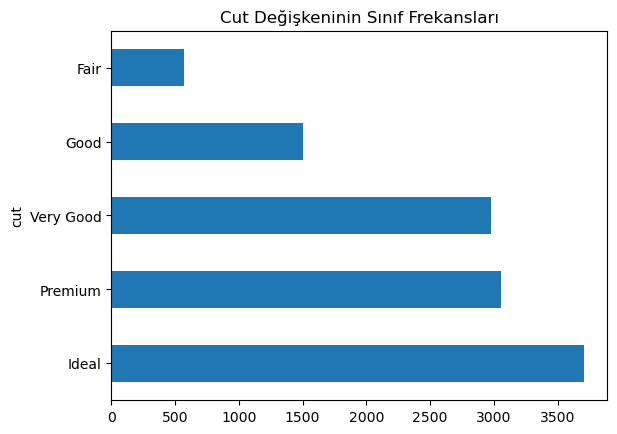

In [52]:
# Barplot Grafiğini Oluşturma(Pandas Aracılığıyla)

df["cut"].value_counts().plot.barh().set_title("Cut Değişkeninin Sınıf Frekansları");

C:\Users\since\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


<Axes: xlabel='cut'>

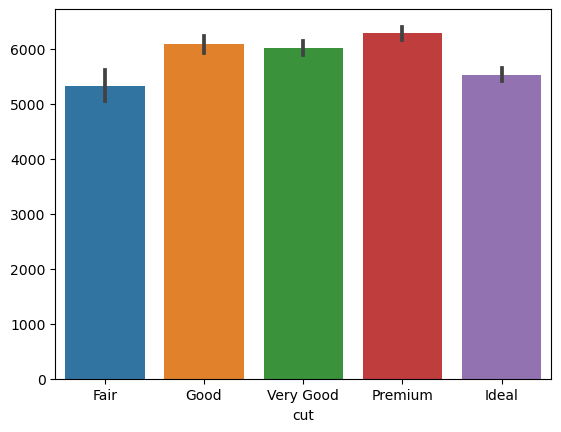

In [53]:
# Barplot Grafiğini Oluşturma(Seaborn Aracılığıyla)

sns.barplot(x="cut", y=df.cut.index, data=df)

# Çaprazlamalar

Çaprazlamalar: Veriseti içerisinde yer alan değişkenlerin birlikte değerlendirilmesi. 

Kırılımları göz önünde bulundurmak

Değişkenlerin etkilerinin birlikte değerlendirilmesi

In [56]:
import seaborn as sns
from pandas.api.types import CategoricalDtype

dataset = sns.load_dataset("diamonds")

df = dataset.copy()

cut_category_order = ["Fair", "Good", "Very Good", "Premium", "Ideal"]

df.cut = df.cut.astype(CategoricalDtype(categories = cut_category_order, ordered=True))

df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


Şimdi "Cut" kategorik değişkeniyle "Price" sayısal değişkenini çaprazlayarak bir arada değerlendireceğiz:

C:\Users\since\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\since\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


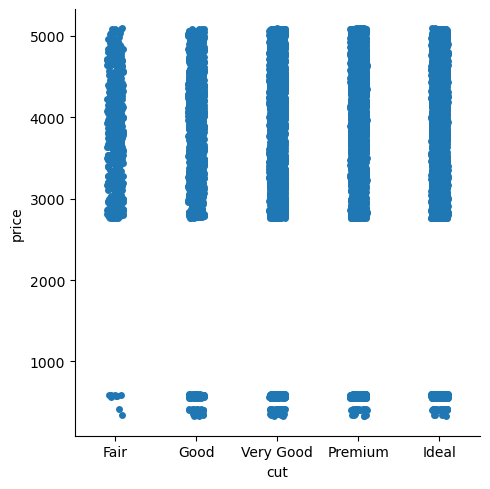

In [58]:
sns.catplot(x="cut", y="price", data=df); 

# kategorik değişkenleri görselleştirmek için catplot fonksiyonu kullanılır
# catplot fonksiyonu varsayılan olarak tüm değeri gösterir.

C:\Users\since\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


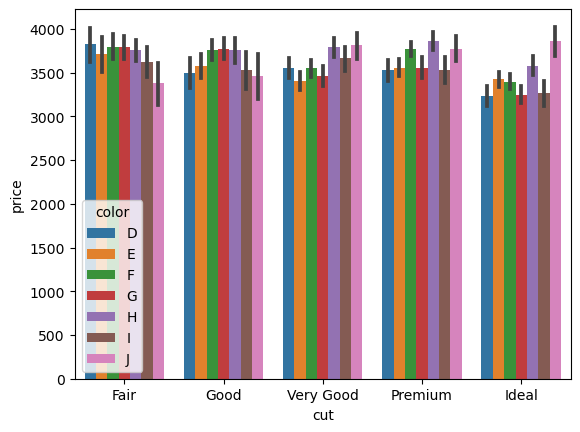

In [59]:
sns.barplot(x="cut", y="price", hue="color", data=df); # barplot fonksiyonu varsayılan olarak mean değerini gösterir.

# burada color sütununu da getirdik. artık price seviyelerindeki colorları da gösteriyor
# yani bu grafik bize 3 tane sütun hakkında bilgi veriyor artık. çaprazla allah çaprazla

In [60]:
# Şimdi bu grafiği valide edelim, yani doğrulayalım. Grafikte price'ın cut ve color değişkenlerine göre mean değerleri gösteriliyormuş. Bakalım öyle mi

df.groupby(["cut","color"])["price"].mean() 

C:\Users\since\AppData\Local\Temp\ipykernel_1680\3335546526.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["cut","color"])["price"].mean()


cut        color
Fair       D        3824.838235
           E        3710.136364
           F        3794.900901
           G        3787.000000
           H        3752.837838
           I        3620.639344
           J        3377.463415
Good       D        3498.427948
           E        3576.403101
           F        3755.118243
           G        3768.846457
           H        3756.267241
           I        3526.314286
           J        3465.525773
Very Good  D        3553.316832
           E        3408.471477
           F        3548.621771
           G        3461.530837
           H        3793.670020
           I        3664.222222
           J        3819.435028
Premium    D        3533.000000
           E        3557.698000
           F        3773.929658
           G        3556.541910
           H        3864.423841
           I        3531.112637
           J        3774.358586
Ideal      D        3236.126016
           E        3424.298165
           F        339

# Histogram ve Yoğunluk Grafiğinin Oluşturulması

Histogram ve Yoğunluk grafikleri **sayısal değişkenler** ve sayısal değişkenlerin dağılımını ifade etmek için kullanılan veri görselleştirme teknikleridir

In [63]:
import seaborn as sns

dataset = sns.load_dataset("diamonds")

df = dataset.copy()

df.head(5)

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


C:\Users\since\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


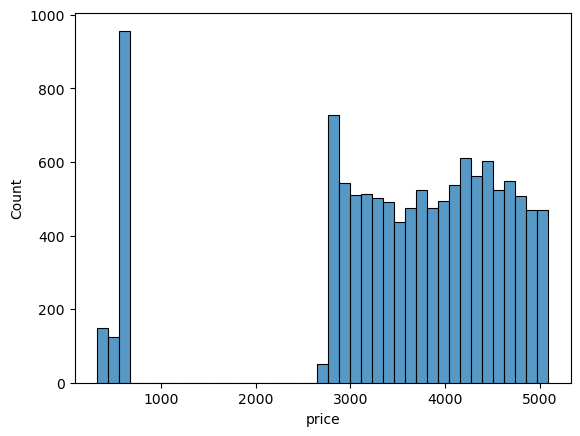

In [64]:
sns.histplot(df.price, kde=False); 

# histplot: Histogram. dağılım görselleştirmek için kullanılan bir fonksiyondur
# grafiği belirli aralıklara böler böler ve sayısal değerlerin dağılımını anlamamıza yardımcı olur
# bins diye bir argümanı var histplot'un. Buna vereceğin değer: grafiğin kaçtane sütunla temsil edeceğidir. bins=10 ise 10 adet kutu kullanılacak

In [65]:
df["price"].describe().T

count    11814.000000
mean      3558.210767
std       1210.698897
min        326.000000
25%       3089.000000
50%       3789.000000
75%       4427.750000
max       5091.000000
Name: price, dtype: float64

# Çaprazlamalar

C:\Users\since\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='price', ylabel='Density'>

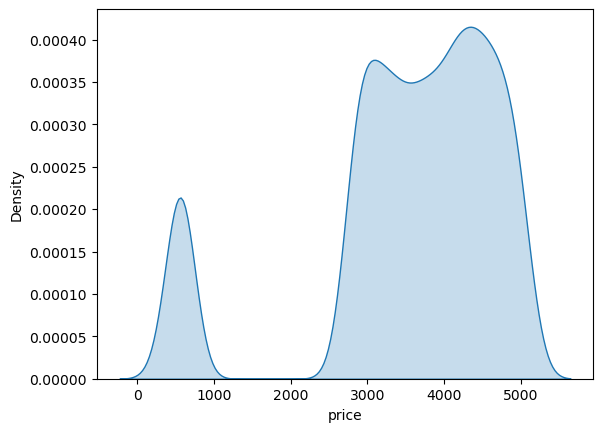

In [67]:
sns.kdeplot(df.price, fill = True)

Genelde sadece tek bir grafiğe bakılarak kararlar alınmaz. O grafiği oluşturan sebepleri ve o grafiğin diğer grafiklerle ilişkisinin de incelenmesi gerekli. Burada Çaprazlama imdadımıza yetişir.

C:\Users\since\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\since\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\since\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\since\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating

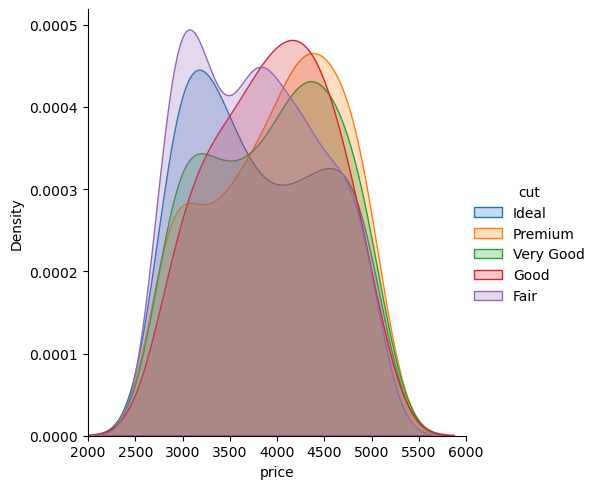

In [69]:
sns.FacetGrid(df, 
              hue="cut",       # Boyutumuz(price'ın kıyaslanacağı sütun/değişken)
              height=5,        # Grafiğin yüksekliği 5 inch olsun
              xlim=(2000,6000) # çizilecek grafik, df'te 2000,6000 değerleri arasını oluştursun, kalanla ilgilenmiyoruz
             ).map(sns.kdeplot, "price", fill=True).add_legend() 
# map ile ana fonksiyonumuzu girdik, bunun hangi grafik(kdeplot) olacağını söyledik, price sütununu söyledik. 
# add_legend() ise cuttaki 5 farklı kategorinin hepsinin eklenmesi için

# FacetGrid fonksiyonu, grafik üzerine eklenen boyutları göstermek için kullanılır
# FacetGrid fonksiyonunu kullanarak tüm cut sınıflarıyla mapleyerek, price'a göre bir kdeplot grafiği oluşturuyoruz.
# Özetle bir yoğunluk grafiği oluşturacağız bir önceki örnekte olduğu gibi fakat buna boyut eklemek istiyoruz, boyutumuz da cut olacak

C:\Users\since\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
C:\Users\since\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


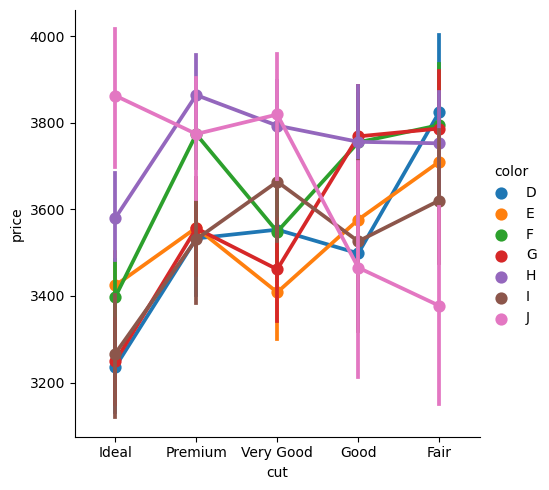

In [70]:
# bir başka grafik daha

sns.catplot(x="cut", y="price", hue="color", kind="point", data=df);

# Boxplot: Kutu Grafiği

Histogram gibi elimizdeki **sayısal değişkenleri** görselleştirmek için kullanılan grafik yöntemidir

Tanımadığımız veriden değer üretmemiz düşünülemez. Bu sebeple yine ilk başta yapacağımız şey, kullanacağımız dataseti tanımak olmalı. Dataseti tanıyalım:

-------------------------------------------------------------------------------------------------------------------

total_bill: yemeğin toplam fiyatı(bahşiş ve vergi dahil)

tip: bahşiş

sex: ücreti ödeyen kişinin cinsiyeti (0 = male, 1 = female)

smoker: grupta sigara içen var mı? (0=No, 1=Yes)

day: gün (3=Thursday, 4=Firday, 5=Saturday, 6=Sunday)

time: ne zaman? (0=Day, 1=Night)

size: grupta kaç kiş var?

In [73]:
import seaborn as sns

dataset = sns.load_dataset("tips")

df = dataset.copy()

df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [74]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
total_bill,244.0,19.785943,8.902412,3.07,13.3475,17.795,24.1275,50.81
tip,244.0,2.998279,1.383638,1.00,2.0000,2.900,3.5625,10.00
size,244.0,2.569672,0.951100,1.00,2.0000,2.000,3.0000,6.00


In [75]:
for i in df.columns:
    if df[i].dtype=="object" or df[i].dtype=="category":
        print("\n",df[i].value_counts())


 sex
Male      157
Female     87
Name: count, dtype: int64

 smoker
No     151
Yes     93
Name: count, dtype: int64

 day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64

 time
Dinner    176
Lunch      68
Name: count, dtype: int64


### Boxplot

In [77]:
import seaborn as sns

dataset = sns.load_dataset("tips")

df = dataset.copy()

df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


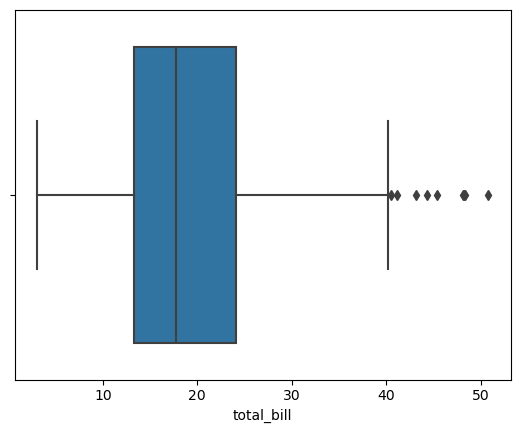

In [78]:
sns.boxplot(x=df["total_bill"]);

# boxplot grafiği, ileride aykırı değer gözleminde de kullanacağımız bir grafik yöntemidir

### Boxplot Çaprazlamalar

In [80]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
total_bill,244.0,19.785943,8.902412,3.07,13.3475,17.795,24.1275,50.81
tip,244.0,2.998279,1.383638,1.00,2.0000,2.900,3.5625,10.00
size,244.0,2.569672,0.951100,1.00,2.0000,2.000,3.0000,6.00


C:\Users\since\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


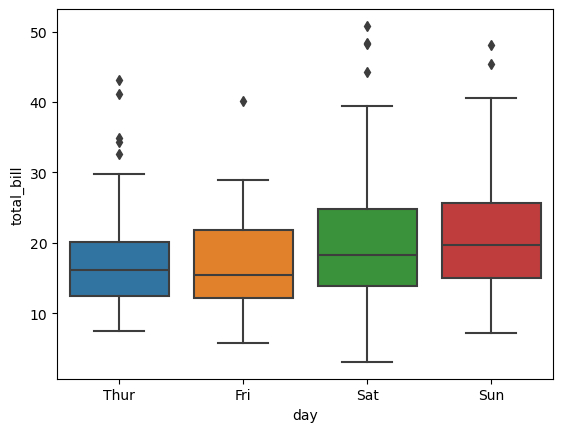

In [81]:
# Soru 1: Hangi günler daha fazla para kazanıyoruz?

sns.boxplot(x="day",y="total_bill", data=df);

# Hangi gün daha fazla kazanıyoruz grafiği. Gün ve Total_bill değişkenlerini bir arada çaprazlayarak oluşan grafik:

C:\Users\since\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


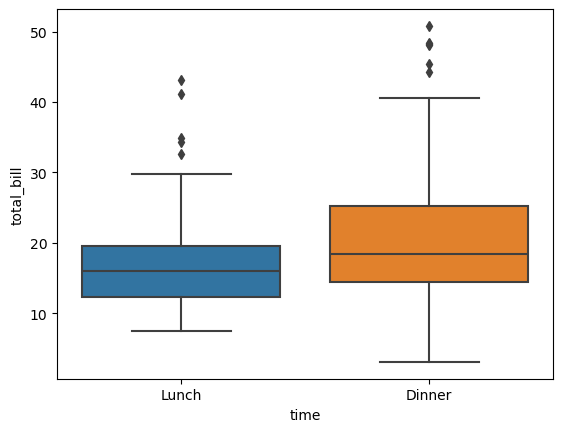

In [82]:
# Soru 2: Sabah mı yoksa akşam mı daha çok kazanıyoruz?

sns.boxplot(x="time", y="total_bill", data=df);

# Akşam daha çok kazanıyormuşuz
# Örneğin bir veribilimcisinden danışmanlık alan bir restorant sahibine bu veri sunulduktan sonra, bu + yukarıdaki veriye dayanarak,
# müşteriye en kaliteli, en iyi, en hızlı hizmeti sunması gerektiği zamanların haftasonu akşamları olduğu bilgisi verilebilir.
# patron buna göre aksiyona geçip gelirini daha da üstlere çekebilir. Tek yapması gereken, bize danışmadan önce müşteriler hakkındaki
# bazı verileri tutmuş olmasını bekleriz

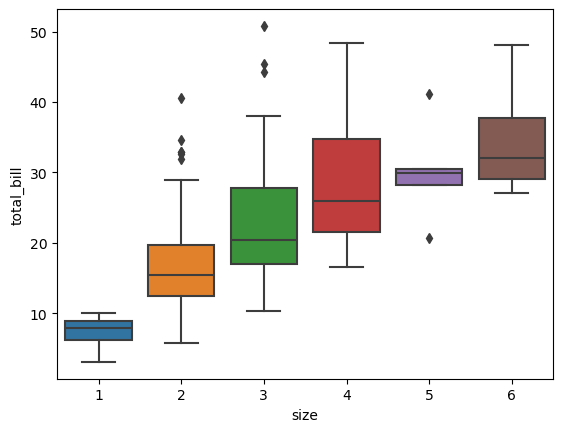

In [83]:
# Kişi sayısı kazancı nasıl etkiliyor?

sns.boxplot(x="size", y="total_bill", data=df);

# doğru kullanım x ekseninde kategorik değişken, y ekseninde sürekli değişkenler olmalı
# sns.boxplot(x="total_bill", y="size", data=df); yazınca grafiğin komple değişmesinin sebebi, size değişkeni discrate numerical bir değişken
# olduğundan dolayı seaborn discrate değerleri kategorik olarak değerlendiriyor. Bu durumda da kategorik değer y ekseninde olmuş oluyor

C:\Users\since\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


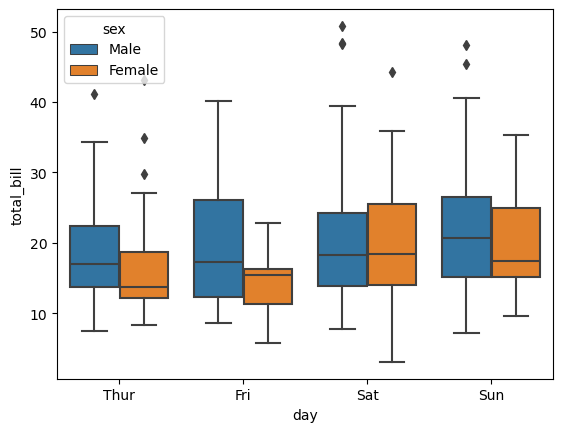

In [84]:
# Cinsiyetlerin günlerde ödediği hesaplar nasıl?

sns.boxplot(x="day", y="total_bill", hue="sex", data=df);

## Violin Grafiği

Violin grafiği boxplot'a benzerdir. 

Dağılım anlamında daha çok bilgi sunar.

Yoğunluk grafiğiyle boxplot grafiğinin kesişimi gibi düşünebiliriz

In [87]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


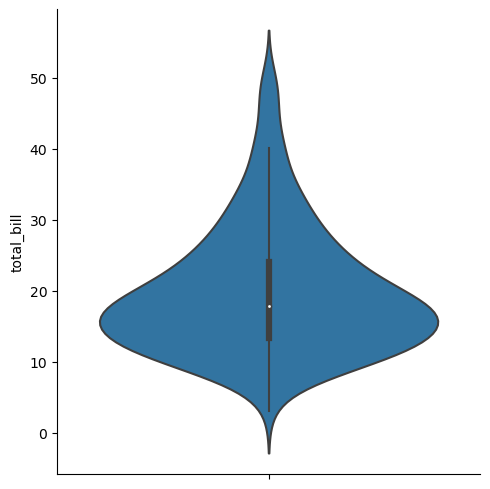

In [88]:
sns.catplot(y="total_bill", kind="violin", data=df);

### Violin Çaprazlamalar

C:\Users\since\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
C:\Users\since\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


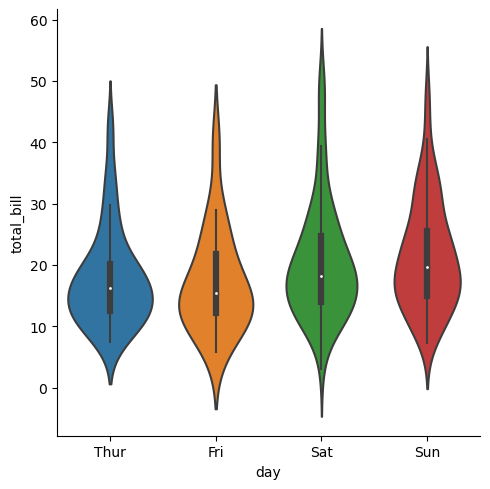

In [90]:
sns.catplot(x="day", y="total_bill", kind="violin", data=df);

C:\Users\since\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
C:\Users\since\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


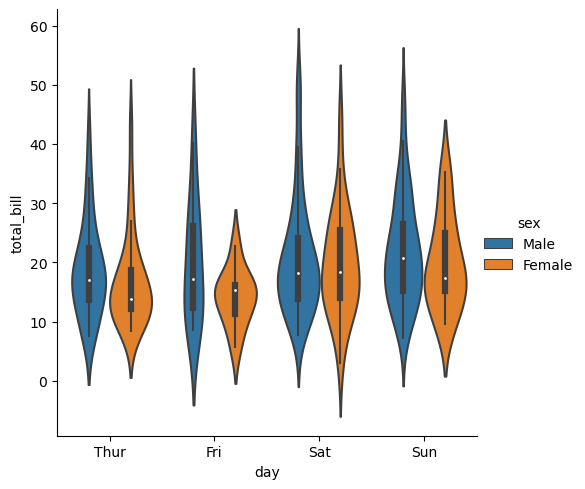

In [91]:
sns.catplot(x="day", y="total_bill", hue="sex", kind="violin", data=df);

# Kırılım, çaprazlama, boyut ekleme. Bu kelimeler başka bir değişken daha koymayı anlatır.

# Korelasyon Grafikleri

Değişkenler arasındaki ilişkiyi ifade eden istatistiksel bir terimdir. Örneğin, "bu iki değişken arasında pozitif korelasyon var" dediğinde, doğru orantılı ilişki var demiş oluyorsun, "negatif korelasyon var" dediğinde ters orantı ilişkisi var demiş oluyorsun. Korelasyonda ayrıyeten korelasyonun gücünü belirten bir katsayı da vardır. Doğru orantı ters orantı mevzusu. Örneğin işin bitme zamanı ile işçi sayısı arasında negatif korelasyon vardır. Egzersiz süresi ile kilo verme hızı arasında pozitif korelasyon vardır.

Korelasyon Katsayısı:
* r = +1: Mükemmel pozitif korelasyon
* r = 0: Korelasyon yok
* r = -1: Mükemmel negatif korelasyon
* |r| > 0.7: Güçlü korelasyon
* 0.3 < |r| < 0.7: Orta korelasyon
* |r| < 0.3: Zayıf korelasyonasyon

## Scatterplot

Scatterplot: Saçılım grafiği. **Sayısal değişkenler** arasındaki ilişkiyi gösterir. bu zamana kadar sayısal değişkenler için olan grafiklerde(histogram, yoğunluk, boxplot, violin) değişkenleri birbirleriyle kıyasladık, çaprazlama yaptık. Scatterplot ve diğer korelasyon grafiklerinde kıyaslama değil, değişkenlerin birlikte oluşturdukları grafikleri göreceğiz

In [96]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


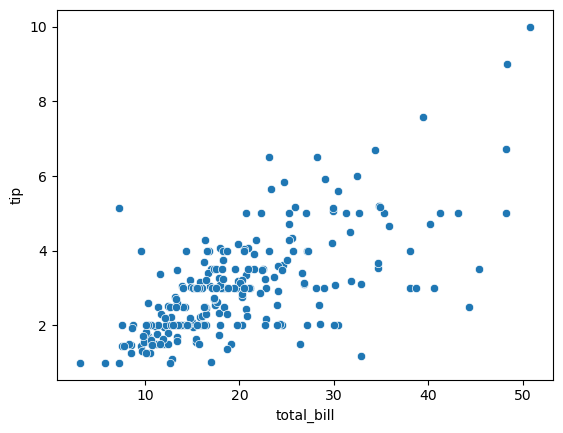

In [97]:
sns.scatterplot(x="total_bill", y="tip", data=df);

# Grafiğin bize anlattığı şey: ödenen hesap miktarı arttıkça bahşiş de artmış. Yani pozitif korelasyon(doğru orantı) var.

### Korelasyon Çaprazlamalar

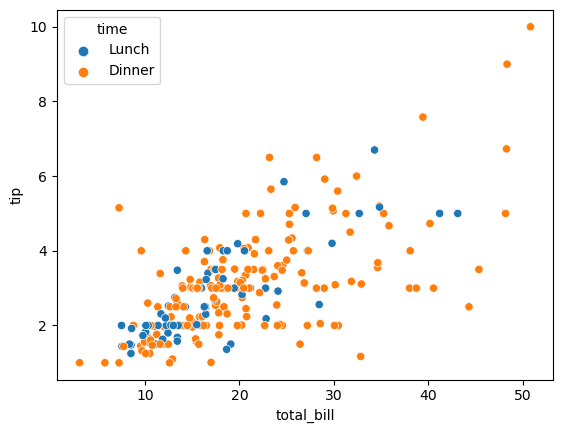

In [99]:
sns.scatterplot(x="total_bill", y="tip", hue="time", data=df);

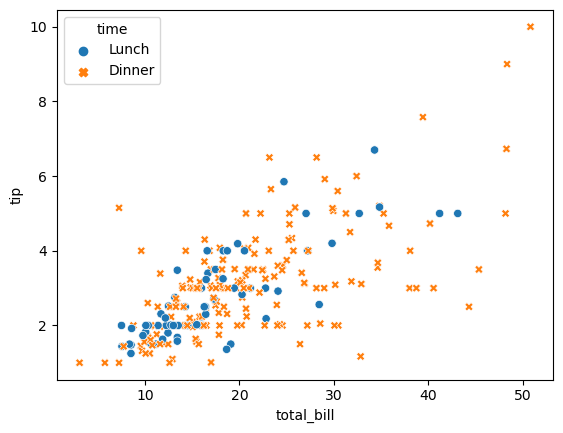

In [100]:
sns.scatterplot(x="total_bill", y="tip", hue="time", style="time", data=df);

# time değişkenini farklı şekilde gösterdi. Dikkatimizi daha çok çekmesi gereken bir veri varsa style argümanını kullanabiliriz

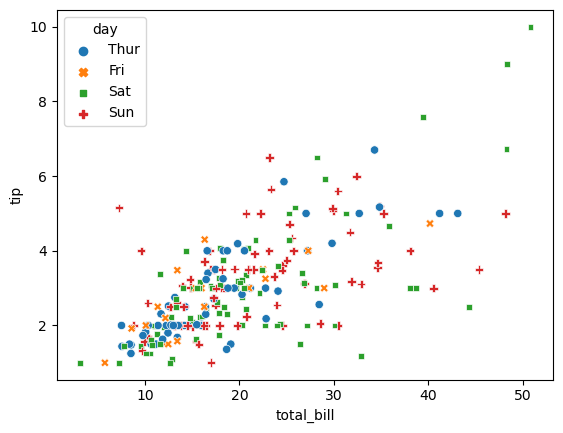

In [101]:
sns.scatterplot(x="total_bill", y="tip", hue="day", style="day", data=df);

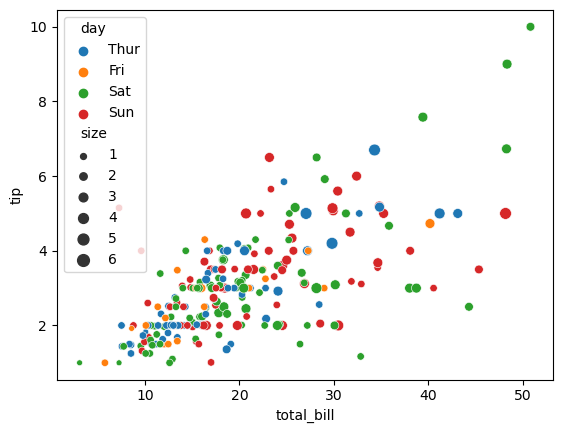

In [102]:
sns.scatterplot(x="total_bill", y="tip", hue="day", size = "size", data=df);

# toplam ödenen hesap ve buna göre tip değişkeninin günler ve gelen kişi sayısına göre(4 parametreli) grafiği. Çok bilgi var

### Doğrusal İlişkinin Gösterilmesi

Scatterplot'a doğru(doğrusal çizgi) eklemek

In [105]:
import seaborn as sns
import matplotlib.pyplot as plt

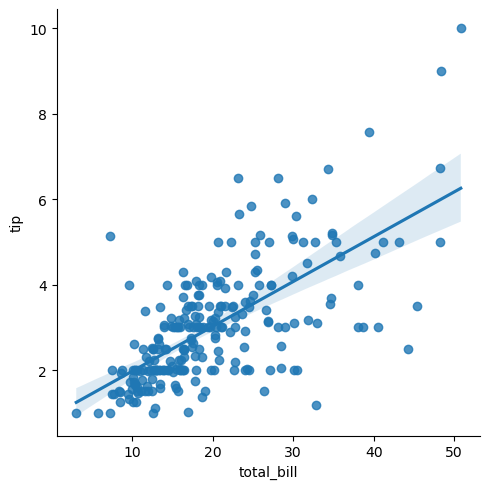

In [106]:
sns.lmplot(x="total_bill", y="tip", data=df); # lm: lineer model. doğrusal çizgi ekleyeceğimizden dolayı bunu kullanıyoruz

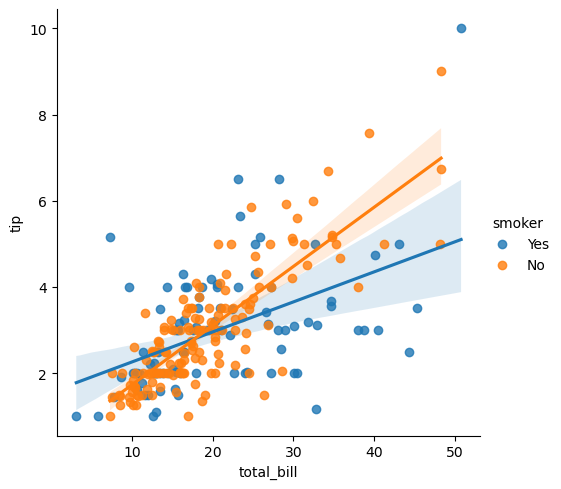

In [107]:
sns.lmplot(x="total_bill", y="tip", hue="smoker", data=df);

# hue ile bir değişken daha eklediğimizde önceki grafikteki doğrumuzun eğimi değişti. 
# Bu durum, ileride eğimden çıkartacağımız makina öğrenmesi algoritmaları/denklemleri konularında çok önemli olacak.
# Yorum yapacağımzı bir diğer şey de, turuncu doğru(sigara içmeyenler) daha yukarıda olduğundan, sigara içmeyenlerin daha fazla bahşiş bıraktığını
# söyleyebiliriz.

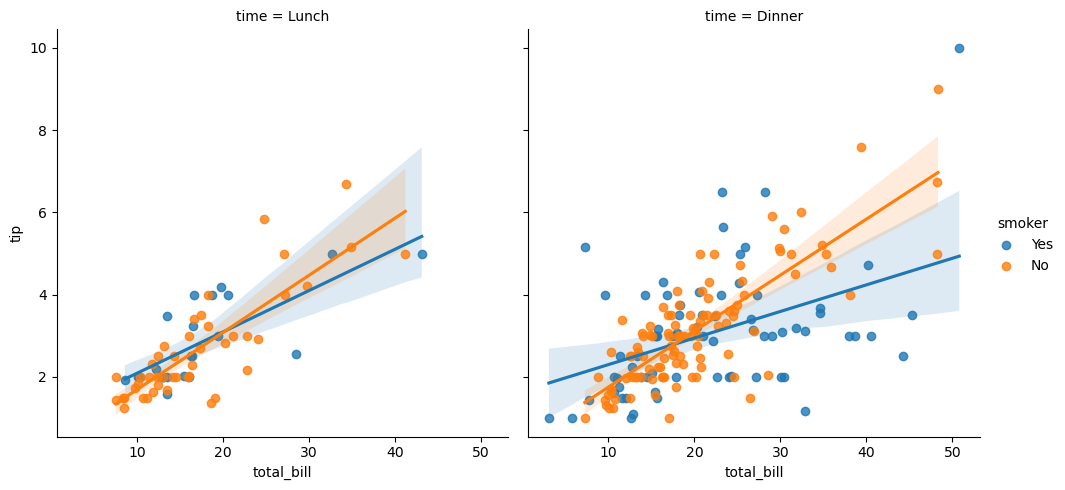

In [108]:
sns.lmplot(x="total_bill", y="tip", hue="smoker", col="time", data=df);

Önemli not: Çaprazlamalar yaptığımız zaman doğruların eğimleri, korelasyon türleri vb'nin değiştiğini söyledik. Peki ya anlamlı bir şekilde mi değişiyor? İlişki anlamlı mı? Korelasyon anlamlı mı? farklılık anlamlı mı? gibi konuların testlerini yapacağız ileride. Yani veri bilimi'nin bilim kısmını ele alacağız.

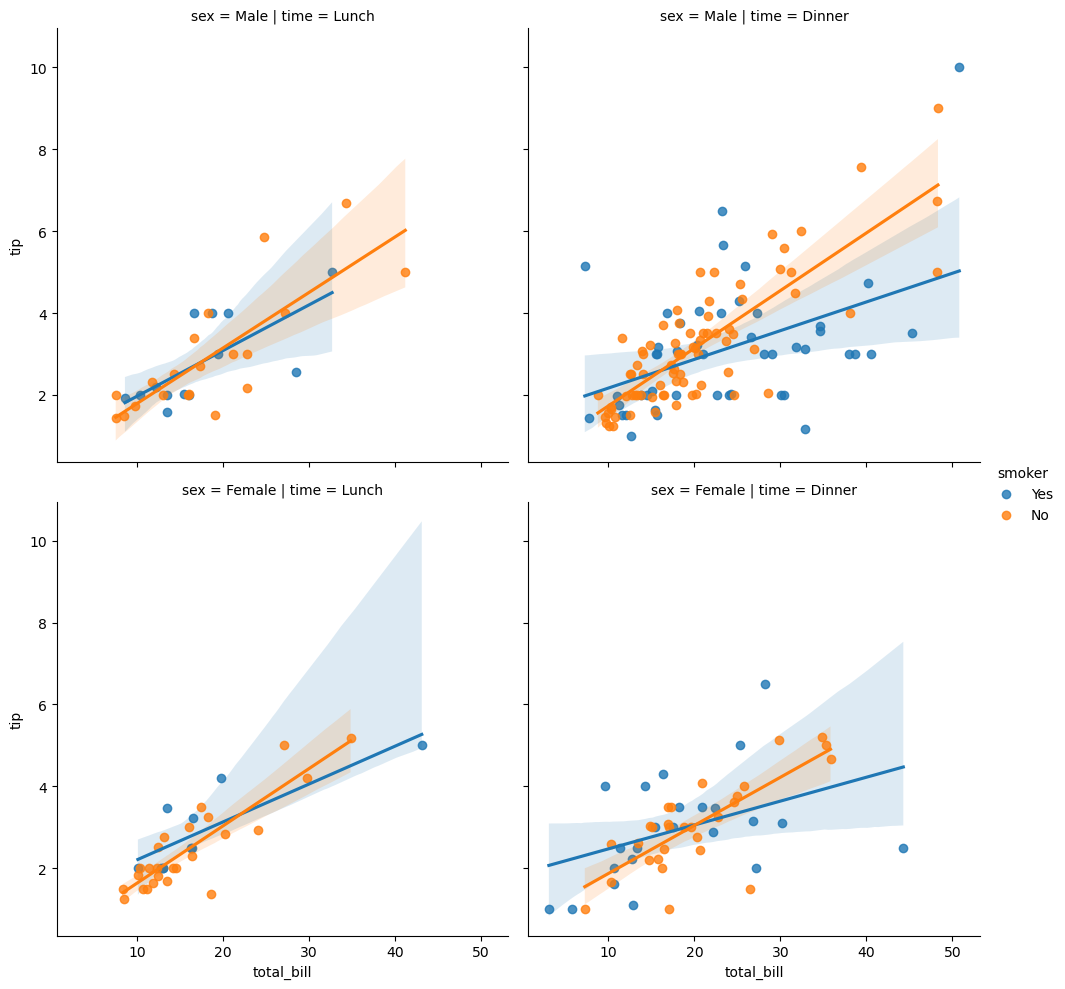

In [110]:
sns.lmplot(x="total_bill", y="tip", hue="smoker", col="time", row="sex", data=df); # bir boyut daha ekledik. Cinsiyet.

### Scatterplot Matrisi

Scatterplot, sayısal değişkenlerin korelasyonunu ifade eder. Scatterplot Matrisi ise bu korelasyonu matris şeklinde ifade eder.

In [113]:
import seaborn as sns

dataset = sns.load_dataset("iris") # çiçek türleri ve bu türlerin özelliklerini barındıran veriseti

df = dataset.copy()

df.head(5)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [114]:
print(df.dtypes)

print(df.shape)

sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object
(150, 5)


C:\Users\since\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\since\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\since\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\since\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating

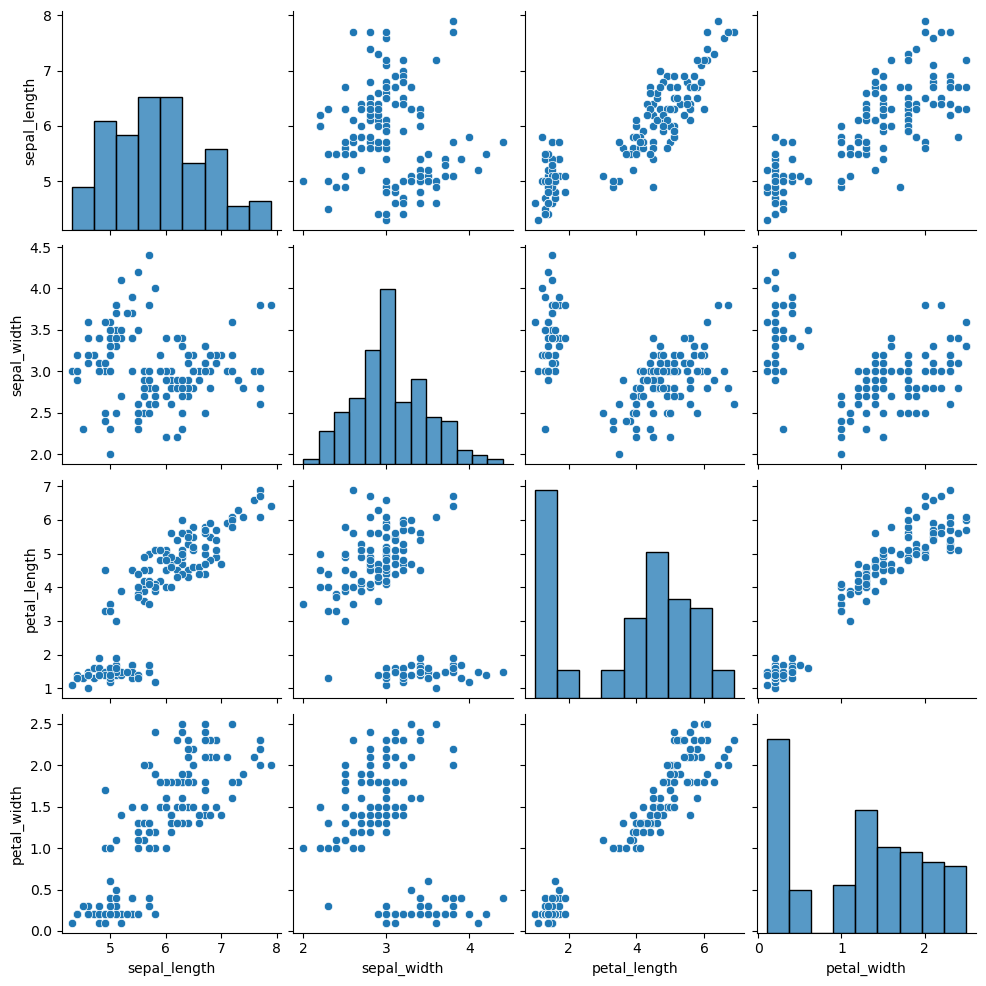

In [115]:
sns.pairplot(df);

# scatterplot görsellerinde oluşan grafik toz bulutu şeklinde ise ya da yapısal formu yoksa, o iki değişken arasında bir ilişki olmadığı anlamına gelir
# scatterplotta oluşan grafikte, birbirinden farklı köşelerde kümelenmeler oluyorsa, çaprazlanmaları ifade eden bazı alt gruplar vardır deriz

C:\Users\since\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\since\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\since\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\since\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating

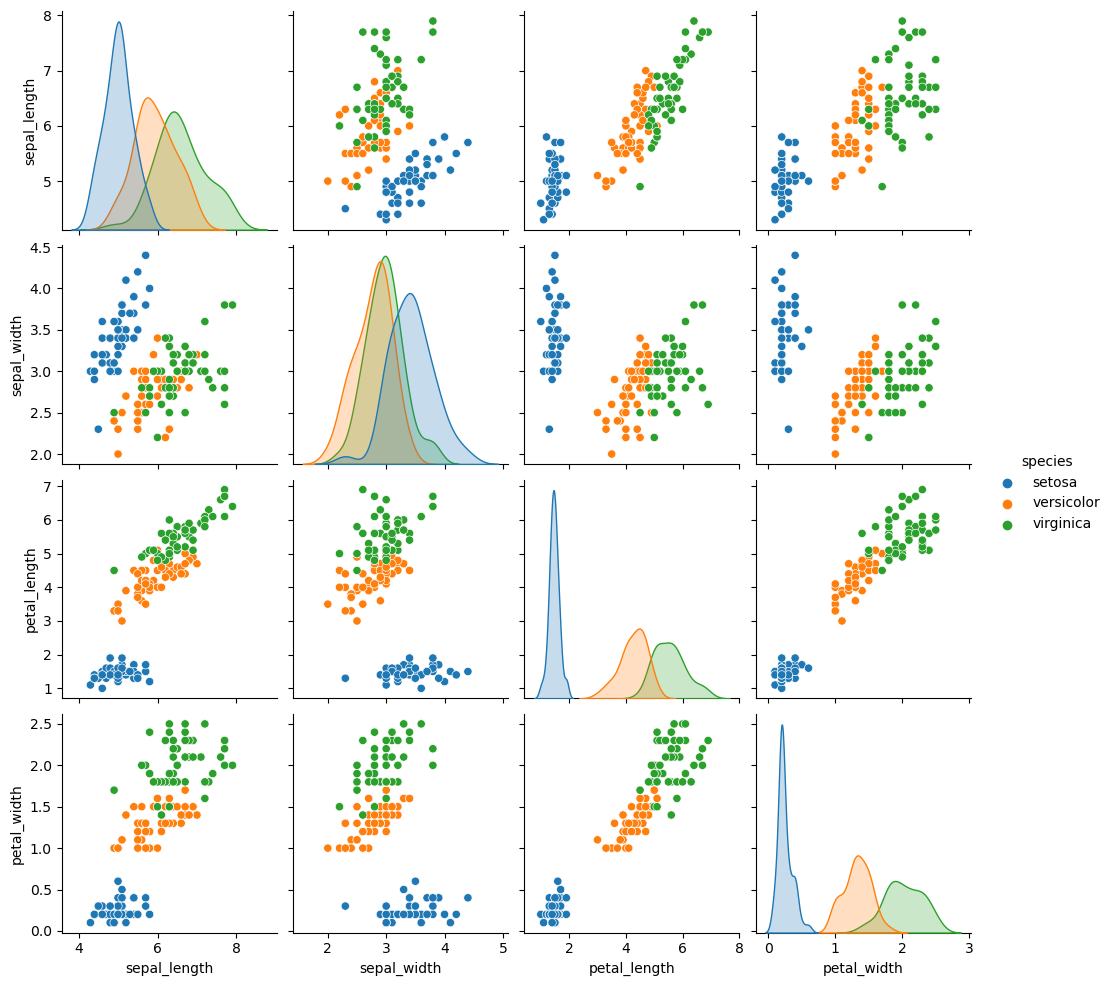

In [116]:
sns.pairplot(df, hue="species"); 

C:\Users\since\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\since\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\since\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\since\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating

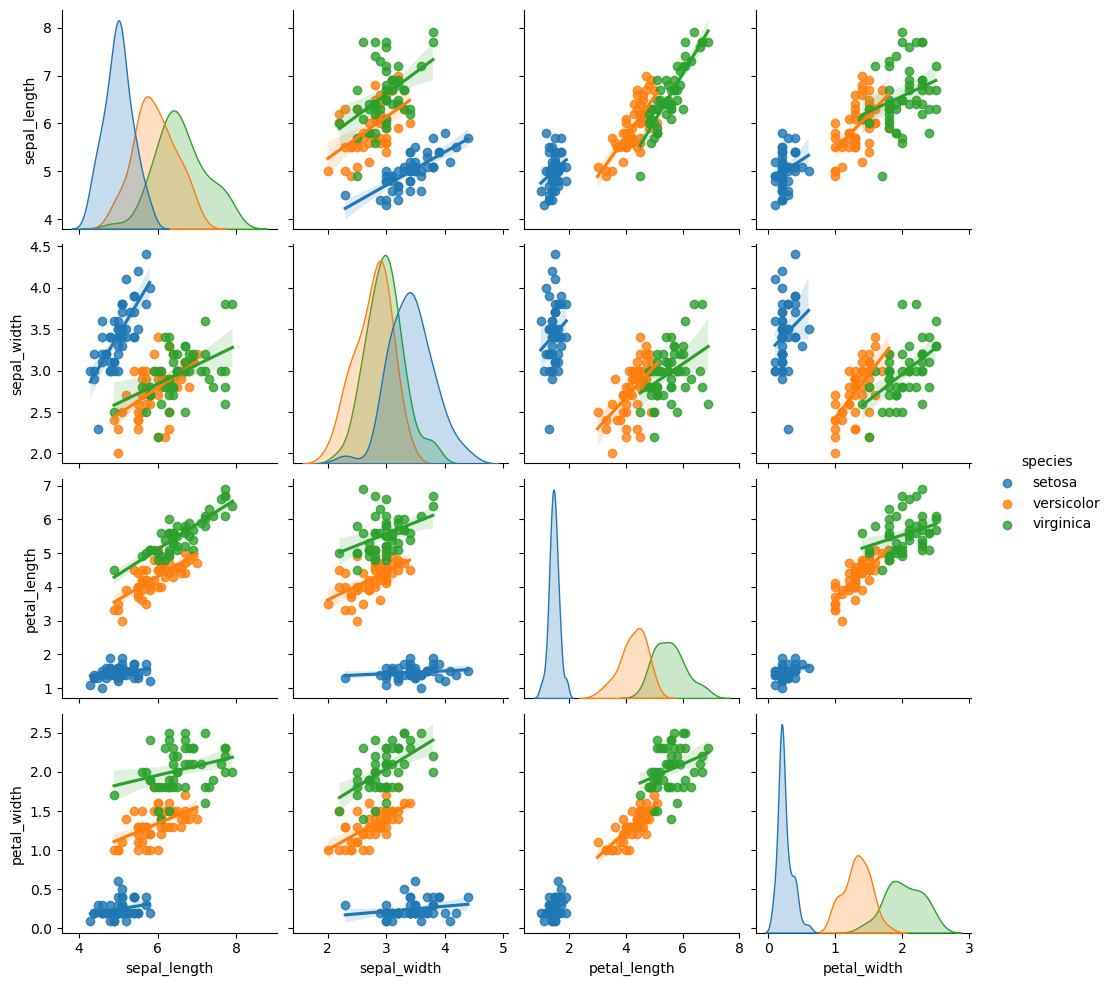

In [117]:
sns.pairplot(df, kind="reg", hue="species");

### Heatmap (Isı Haritası)

Elimizdeki verileri daha geniş perspektiften görmek istediğimizde kullanabileceğimiz bir grafik türüdür. Belirli periyotlarla tekrar(gün,hafta,ay,yıl, vb) eden olayları görmek istediğimizde kullanımı çok faydalı bir grafiktir

In [120]:
import seaborn as sns

dataset=sns.load_dataset("flights")

df=dataset.copy()

print(df.head(5))

print(df.tail(5))

   year month  passengers
0  1949   Jan         112
1  1949   Feb         118
2  1949   Mar         132
3  1949   Apr         129
4  1949   May         121
     year month  passengers
139  1960   Aug         606
140  1960   Sep         508
141  1960   Oct         461
142  1960   Nov         390
143  1960   Dec         432


In [121]:
df.shape

(144, 3)

In [122]:
sns.heatmap(df);

# heatmap bizden dataframelerimizi, ona pivot olarak vermemizi ister. bu sebeple hata aldık, dataframe'i pivota çevirelim:

ValueError: could not convert string to float: 'Jan'

In [ ]:
df = df.pivot(index="month", columns="year", values="passengers") 

# ilk yazılan argüman x ekseni, ikinci y ekseni, son kısım; kesişimlerinde yer alacak sürekli değişken

In [ ]:
df

In [ ]:
sns.heatmap(df);

In [ ]:
sns.heatmap(df, annot=True, fmt="d", linewidths=0.5);

## Çizgi Grafik

Daha zor problemlerde kullanacağımız veri görselleştirme türü. Zamana bağlı değişkenlerin olduğu verisetlerinde ve nesnelerin interneti, makinaların ürettiği verileri görselleştirmek için kullanabileceğimiz bir grafik türüdür.

In [ ]:
import seaborn as sns

dataset = sns.load_dataset("fmri") # beyne bağlanan bir cihaz aracılığıyla toplanan verileri tutan bir veriseti

df=dataset.copy()

df.head()

In [ ]:
df["timepoint"].describe()

In [ ]:
df["signal"].describe()

In [ ]:
df["event"].value_counts()

### Çizgi Grafik ve Çaprazlamalar

In [ ]:
sns.lineplot(x="timepoint", y = "signal", data=df);

# görülen mavi çizgi ortalamaları, onun dışındaki tabaka ise standart sapmaları ifade ediyor.

In [ ]:
sns.lineplot(x="timepoint", y="signal", hue="event", data=df); # çaprazlama yaptık, event'i de ekledik

In [ ]:
sns.lineplot(x="timepoint", 
             y="signal", 
             hue="event", 
             style="event", 
             markers=True, 
             dashes=False, 
             data=df); 

# mean değerlerini grafik üzerinde işaretleyecek

In [ ]:
sns.lineplot(x="timepoint", 
             y="signal", 
             hue="region", 
             style="event",  
             data=df);

# region değişkenini 3.boyut olarak ekledik

Önemli not: Nasıl ki ordinal değerleri gidip pythona bildirmiştik, hangisi daha önemli diye. **Zaman değişkenlerinin** de aynı şekilde bildirilmesi gerekli: pd.DatetimeIndex(df.timecolumn.index)